In [0]:
osha = spark.read.table('default.osha_injury_tracking_application_2020_2023_20_csv')

In [0]:
osha = osha.na.drop(subset=["annual_average_employees",
                            "total_hours_worked",
                            "total_injuries",
                            "Industry Name",
                            "state"])

(oshaTrain, oshaTest) = osha.randomSplit([0.8,0.2])

In [0]:
from pyspark.sql.functions import log1p, col, when
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml import Pipeline

oshaTrain = oshaTrain.withColumn("log_hours", log1p(col("total_hours_worked")))

cat_cols   = ["state", "Industry Name"]
indexers   = [StringIndexer(inputCol=c, outputCol=f"{c}_idx",
                            handleInvalid="keep") for c in cat_cols]
encoders   = [OneHotEncoder(inputCol=f"{c}_idx", outputCol=f"{c}_vec")
              for c in cat_cols]

num_cols   = ["annual_average_employees", "total_hours_worked"]

assembler  = VectorAssembler(
                inputCols=[f"{c}_vec" for c in cat_cols] + num_cols,
                outputCol="features")

Gradient-boosted tree

In [0]:
from pyspark.ml.regression import GBTRegressor

In [0]:
gbt = GBTRegressor(labelCol="total_injuries", featuresCol="features") 

In [0]:
pipeline = Pipeline(stages=indexers + encoders + [assembler, gbt])
model    = pipeline.fit(oshaTrain)
preds    = model.transform(oshaTest)

In [0]:
preds.show()

+-------+--------------------+--------------------+---------+--------------------+-----------------+-----+--------+----------+--------------------+------------------------+------------------+---------------------+------------+----------------+----------------+-----------------+---------------+---------------+--------------+----------------+----------------------------+--------------------+------------------+---------------------+----------------+------------------+----+---------------+--------+--------------------+---------+--------------------+---------+-----------------+---------------+-----------------+--------------------+--------------------+
|     id|        company_name|  establishment_name|      ein|      street_address|             city|state|zip_code|naics_code|industry_description|annual_average_employees|total_hours_worked|no_injuries_illnesses|total_deaths|total_dafw_cases|total_djtr_cases|total_other_cases|total_dafw_days|total_djtr_days|total_injuries|total_poisonings|to

Evalutation of the model

In [0]:
from pyspark.ml.evaluation import RegressionEvaluator

rmse_evaluator = RegressionEvaluator(
                     labelCol="total_injuries",
                     predictionCol="prediction",
                     metricName="rmse")

mae_evaluator  = RegressionEvaluator(
                     labelCol="total_injuries",
                     predictionCol="prediction",
                     metricName="mae")

rmse = rmse_evaluator.evaluate(preds)
mae  = mae_evaluator.evaluate(preds)

print(f"RMSE : {rmse:0.4f}")
print(f"MAE  : {mae:0.4f}")

RMSE : 11.4814
MAE  : 2.9103


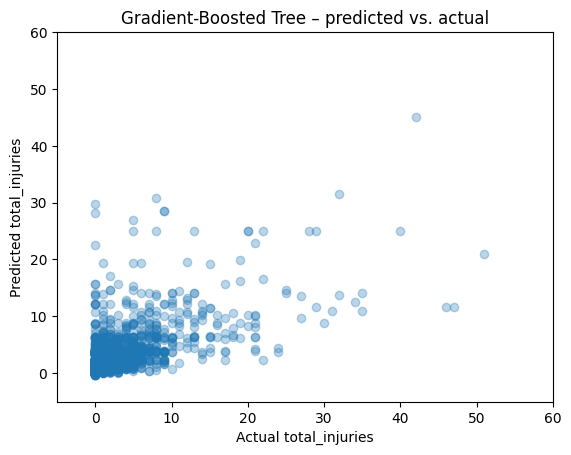

In [0]:
from pyspark.sql import functions as F

(sample_pd, _) = preds.orderBy(F.rand()).limit(2000).toPandas(), None

import matplotlib.pyplot as plt
plt.scatter(sample_pd["total_injuries"], sample_pd["prediction"], alpha=0.3)
plt.xlabel("Actual total_injuries")
plt.ylabel("Predicted total_injuries")
plt.title("Gradient-Boosted Tree – predicted vs. actual")
plt.xlim(xmin=-5,xmax=60)
plt.ylim(ymin=-5,ymax=60)
plt.show()

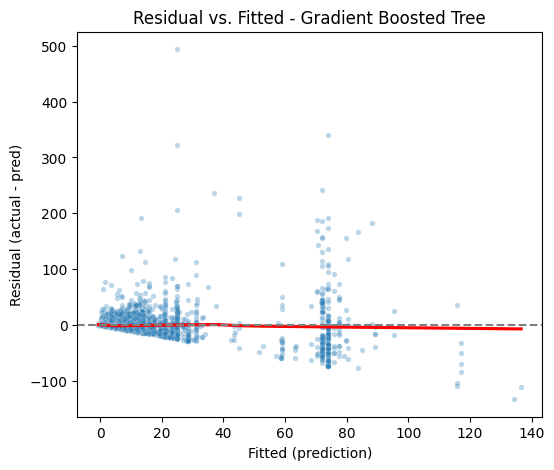

In [0]:
sample = (preds
            .select("prediction", "total_injuries")
            .withColumn ("resid", F.col("total_injuries") - F.col ("prediction"))
            .sample(0.1, seed=42)
            .toPandas())

import seaborn as sns

plt.figure(figsize=(6,5))
sns.scatterplot(x="prediction", y="resid", data=sample, alpha=0.3, s=15) 
sns.regplot(x="prediction", y="resid", data=sample,
scatter=False, lowess=True, color="red")
plt.axhline(0, ls="--", c="grey")
plt.xlabel("Fitted (prediction)")
plt.ylabel("Residual (actual - pred)")
plt.title("Residual vs. Fitted - Gradient Boosted Tree")
plt.show()